# *Setup*

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.eda import boxplot, barplot_with_percent, barplot_with_percent_target, cramerv_inputs_target
from src.preprocessing import detect_empty_string, clean_data_eda

**(EN)**
# Preliminary Analysis
#### Dataset Overview:
- 21 columns, with 20 variables in total and 1 ID column;
- 7043 samples;
- 1 output variable, `Churn`, binary categorical;
- 19 input variables:
  - 3 numeric variables, all non-negative;
  - 16 categorical variables:
    - 5 binary;
    - 9 multiclass with 3 classes;
    - 1 multiclass with 4 classes;
- 4 variables identifying customer aspects external to the type of service offered;
- 15 variables with aspects of the service type.

#### Data Cleaning Observations:
- Removal of `customerID`;
- Conversions:
  - `SeniorCitizen` > `object`;
  - `tenure` > `float`;
  - `TotalCharges` > `float`;
- Missing data:
  - `TotalCharges`:
    - In the form of empty strings `' '`:
    - All corresponding to clients with a tenure of 0 months;
    - Corresponding values in `MonthlyCharges` are not missing, therefore, they will be used for completion.

#### **Conclusion:**
> Observed data cleaning steps compiled in `src.preprocessing.clean_data`.
---
**(PT-BR)**
# Análise Preliminar
#### Visão Geral do *Dataset*:
- 21 colunas, com 20 variáveis no total e 1 coluna de id;
- 7043 amostras no total;
- 1 variável de saída, `Churn`, categórica binária;
- 19 variáveis de entrada:
  - 3 variáveis numéricas, todas não negativas;
  - 16 variáveis categóricas:
    - 5 binárias;
    - 9 multiclasse com 3 classes;
    - 1 multiclasse com 4 classes;
- 4 variáveis identificando aspectos do cliente externos ao tipo de serviço ofertado;
- 15 variáveis com aspectos do tipo de serviço.

#### Observações de *Data Cleaning*:
- Remoção de `customerID`;
- Conversões:
  - `SeniorCitizen` > `object`;
  - `tenure` > `float`;
  - `TotalCharges` > `float`;
- Dados faltantes:
  - `TotalCharges`:
    - No formato de strings vazias `' '`:
    - Todos correspondentes a clientes com tempo de permanência (`tenure`) de 0 meses;
    - Valores correspondentes em `MonthlyCharges` não estão faltantes, logo, serão utilizados para preenchimento.

#### **Conclusão:**
> Etapas observadas de *data cleaning* compiladas em `src.preprocessing.clean_data`.

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [6]:
detect_empty_string(df=df)

Index(['TotalCharges'], dtype='object')

In [7]:
df.loc[np.where(df.loc[:, 'TotalCharges'] == ' ')[0]]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**(EN)**
# Univariate and Bivariate Analyses
#### Observations:
- There are no outliers, except when considering values within the output class "Yes" for `Churn`, within the variables `tenure` and `TotalCharges`;
- The dataset is unbalanced: the number of customers who churned is, proportionally, approximately 3 times smaller than the number of customers who remain;
- The type of contract (`Contract`) shows the strongest association with retention or not:
  - Customers with annual contracts have a churn rate approximately **4 times** lower compared to customers with monthly contracts;
  - Customers with biennial contracts have a churn rate approximately **15 times** lower compared to customers with monthly contracts;
- The type of payment (`PaymentMethod`) shows a strong association with customer retention or not:
  - Customers paying with Electronic Check have a Churn rate approximately **3x** lower compared to automatic models (bank transfer and credit card) and **2x** lower compared to Mailed Check;
- The customer's gender does not show an association with Churn;
- Having or not having contracted the telephone service (`PhoneService`) does not show an association with Churn.

#### Conclusions:
> - A good data split (training/testing or k-fold cross-validation) should preserve the proportion of the output class due to imbalance;
> - During the evaluation of predictive models, the accuracy metric becomes less important due to imbalance;
> - From a decision-making perspective, given that the type of contract (`Contract`) and the type of payment (`PaymentMethod`) are strongly associated with Churn, retention strategies that focus on migrating the contract type to longer-term contracts and the payment method to automatic ones should be tested gradually, with the offer of discounts and other incentives. It is important to point out, however, that association does not imply causality, and that these variables may only be reflecting the true cause of lower Churn rates, where customers already inclined to remain tend to opt for plans with greater loyalty and payment methods that require less manual intervention;
> - From a modeling perspective, variables that do not show an association with Churn may not be used by the models due to their lower discriminatory power, and may be removed, simplifying interpretability, computational cost, and even improving performance due to the lower chance of introducing noisy information;
> - From a decision-making perspective, outliers within the "Yes" class conditioning, in regions not considered outliers by the "No" class, demonstrate customers whose tendency would be to remain. Retention strategies should focus on making high-value customers with long service tenures feel important and have some status relative to others.

---
**(PT-BR)**
# Análises Univariadas e Bivariadas
#### Observações:
- Não há *outliers*, somente se considerarmos os valores dentro da classe de saída *Yes* para `Churn`, dentro das variáveis `tenure`e `TotalCharges`;
- O *dataset* é desbalanceado: o número de clientes que deram *Churn* é, em proporção, aproximadamente 3x menor do que clientes que permanecem;
- O tipo de contrato (`Contract`) demonstra a associação mais forte com a permanência ou não:
  - Clientes com contrato anual apresentam proporção de *Churn* aproximadamente **4x** menor em relação a clientes com contrato mensal;
  - Clientes com contrato bienal apresentam proporção de *Churn* aproximadamente **15x** menor em relação a clientes com contrato mensal;
- O tipo de pagamento (`PaymentMethod`) demonstra forte associação com a permanência ou não:
  - Clientes com pagamento do tipo *Eletronic Check* apresentam proporção de *Churn* aproximadamente **3x** menor em relação aos modelos automáticos (transferência bancária e cartão de crédito) e **2x** menor em relação ao *Mailed Check*;
- O gênero do cliente (`gender`) não demonstra associação com a prática de *Churn*;
- Ter contratado ou não o serviço telefônico (`PhoneService`) não demonstra associação com a prática de *Churn*.

#### Conclusões:
> - Uma boa divisão de dados (treinamento/teste ou validação cruzada k-fold) deve preservar a proporção da classe de saída devido ao desbalanceamento;
> - Durante a avaliação dos modelos preditivos, a métrica de acurácia passa a ter uma menor importância devido ao desbalanceamento;
> - Do ponto de vista de tomada de decisão, dado que o tipo de contrato (`Contract`) e o tipo de pagamento (`PaymentMethod`) têm forte associação com a prática de *Churn*, estratégias de retenção que focam na migração do tipo do contrato para os mais estendidos e do tipo de pagamento para os automáticos devem ser experimentadas gradualmente, com a oferta de descontos e outros incentivos. É importante pontuar, no entanto, que a associação não significa causalidade, e que estas variáveis podem somente estar refletindo a verdadeira causa de menores taxas de *Churn*, em que clientes já propensos a permanecer tendem a optar por planos com maior fidelidade e modalidades de pagamento que lhes necessite menor intervenção manual;
> - Do ponto de vista de modelagem, variáveis que não demonstram associação com a prática de `Churn` podem não ser utilizadas pelos modelos devido ao menor poder discriminativo, podendo ser retiradas, simplificando em interpretabilidade, custo computacional e até mesmo melhorando a performance devido à menor chance da introdução de informações ruidosas;
> - Do ponto de vista de tomada de decisão, os *outliers* dentro do condicionamento pela classe *Yes*, em regiões em que a classe *No* não considera como *outliers* demonstram clientes cuja tendência seria de permanência. Estratégias de retenção deveriam focar atenção em fazer clientes de alto valor total e com alto tempo de permanência no serviço se sentirem importantes e com algum status em relação aos outros.

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data_eda(df=df)
#df.to_csv('../data/processed/WA_Fn-UseC_-Telco-Customer-Churn_eda.csv')
display(df.head())
display(df.info())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


None

## Numeric Variables/ Variáveis Numéricas

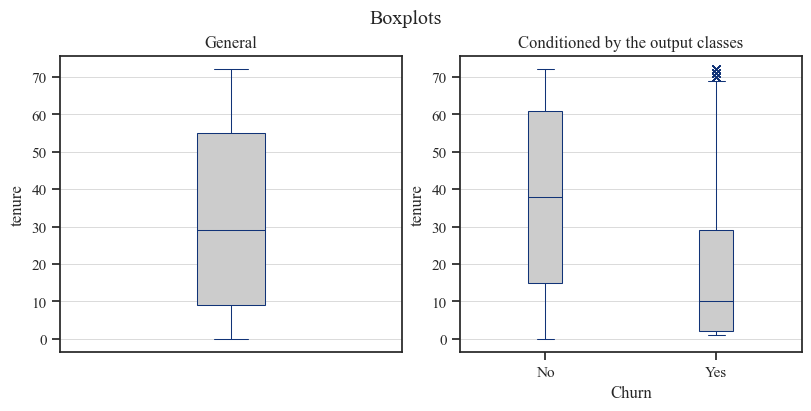

In [4]:
boxplot(plot=False, save=True, df=df, feature_name='tenure', path='../reports/figures/pt-br/boxplot_tenure.png', plot_language='pt-br')
boxplot(plot=True,  save=True, df=df, feature_name='tenure', path='../reports/figures/en/boxplot_tenure.png', plot_language='en')

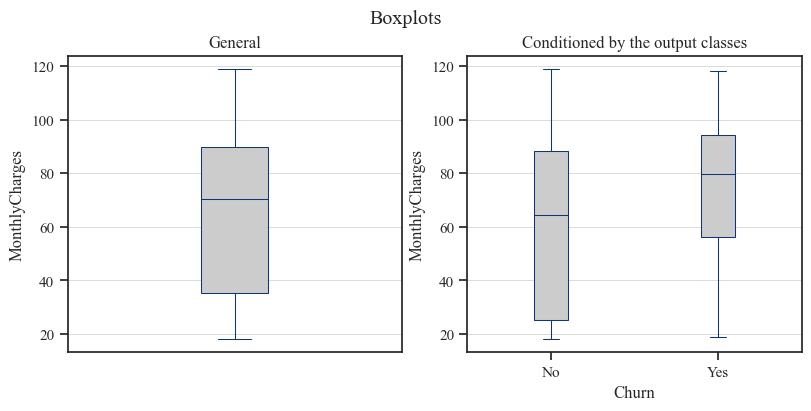

In [5]:
boxplot(plot=False, save=True, df=df, feature_name='MonthlyCharges', path='../reports/figures/pt-br/boxplot_MonthlyCharges.png', plot_language='pt-br')
boxplot(plot=True,  save=True, df=df, feature_name='MonthlyCharges', path='../reports/figures/en/boxplot_MonthlyCharges.png', plot_language='en')

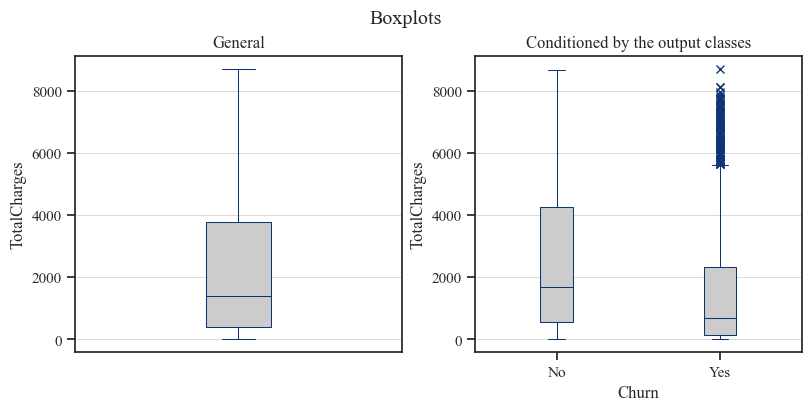

In [6]:
boxplot(plot=False, save=True, df=df, feature_name='TotalCharges', path='../reports/figures/pt-br/boxplot_TotalCharges.png', plot_language='pt-br')
boxplot(plot=True,  save=True, df=df, feature_name='TotalCharges', path='../reports/figures/en/boxplot_TotalCharges.png', plot_language='en')

## Categorical Variables/ Variáveis Categóricas

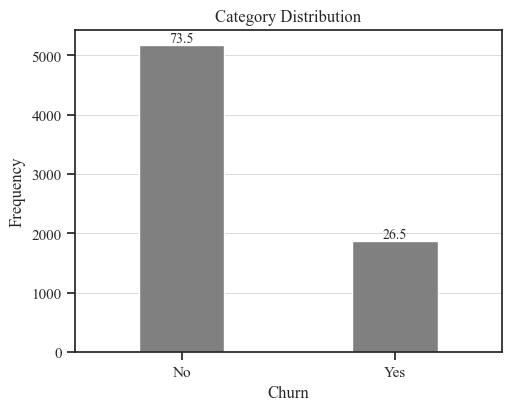

In [7]:
barplot_with_percent_target(plot=False, save=True, df=df, path='../reports/figures/pt-br/barplot_Churn.png', plot_language='pt-br')
barplot_with_percent_target(plot=True,  save=True, df=df, path='../reports/figures/en/barplot_Churn.png', plot_language='en')

In [8]:
cramerv_inputs_target(df=df.loc[:, df.dtypes=='object'], target_column='Churn',
                      style_format='standard', significance=0.05, save=True,
                      path='../reports/tables/chi2-test_results.csv', display_language='en')

,V,Chi2,p-value,Degrees of Freedom,Association's Degree
Contract,0.4101,1184.6,0.000,2,strong
OnlineSecurity,0.3474,850.,0.000,2,strong
TechSupport,0.3429,828.2,0.000,2,strong
InternetService,0.3225,732.31,0.000,2,strong
PaymentMethod,0.3034,648.14,0.000,3,strong
OnlineBackup,0.2923,601.81,0.000,2,strong
DeviceProtection,0.2816,558.42,0.000,2,strong
StreamingMovies,0.2310,375.66,0.000,2,moderate
StreamingTV,0.2305,374.20,0.000,2,moderate
PaperlessBilling,0.1915,258.28,0.000,1,weak


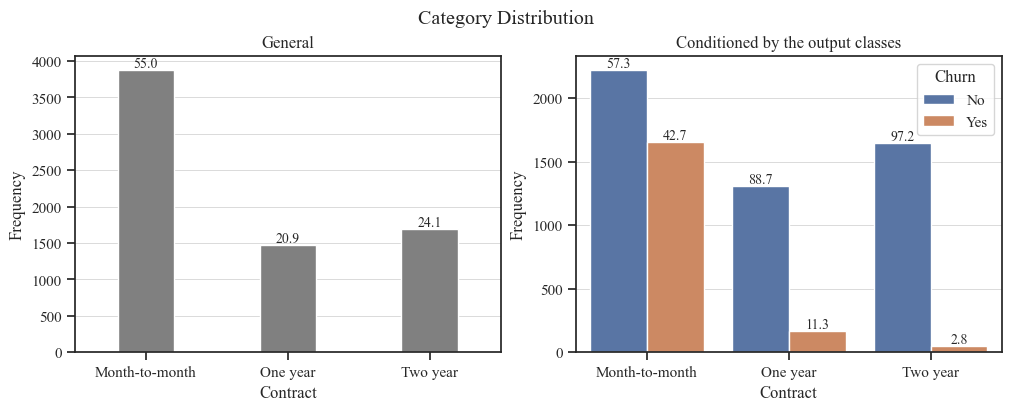

In [9]:
barplot_with_percent(plot=False, save=True, df=df, feature_name='Contract',
                     path='../reports/figures/pt-br/barplot_Contract_Churn.png', plot_language='pt-br')
barplot_with_percent(plot=True,  save=True, df=df, feature_name='Contract',
                     path='../reports/figures/en/barplot_Contract_Churn.png', plot_language='en')

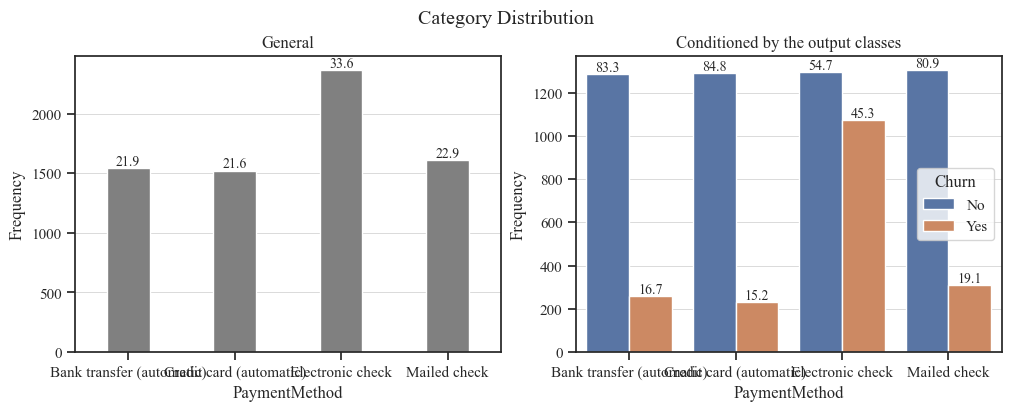

In [10]:
barplot_with_percent(plot=False, save=True, df=df, feature_name='PaymentMethod',
                     path='../reports/figures/pt-br/barplot_PaymentMethod_Churn.png', plot_language='pt-br')
barplot_with_percent(plot=True,  save=True, df=df, feature_name='PaymentMethod',
                     path='../reports/figures/en/barplot_PaymentMethod_Churn.png', plot_language='en')

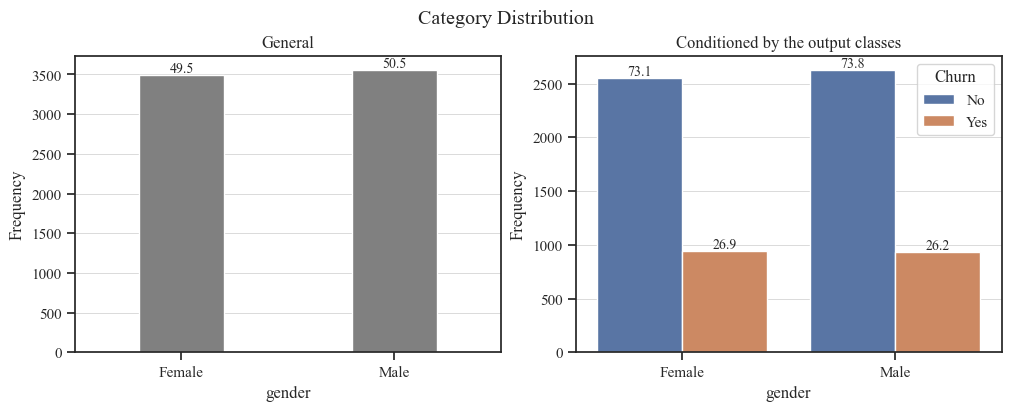

In [11]:
barplot_with_percent(plot=False, save=True, df=df, feature_name='gender',
                     path='../reports/figures/pt-br/barplot_gender_Churn.png', plot_language='pt-br')
barplot_with_percent(plot=True,  save=True, df=df, feature_name='gender',
                     path='../reports/figures/en/barplot_gender_Churn.png', plot_language='en')

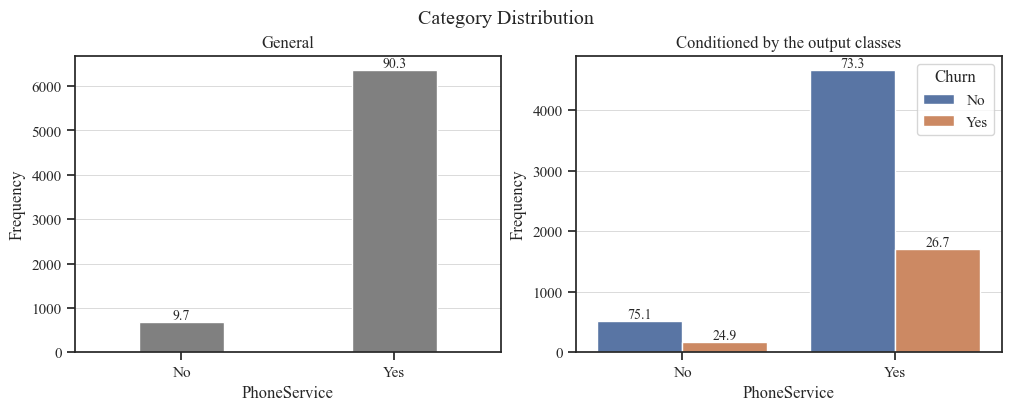

In [12]:
barplot_with_percent(plot=False, save=True, df=df, feature_name='PhoneService',
                     path='../reports/figures/pt-br/barplot_PhoneService_Churn.png', plot_language='pt-br')
barplot_with_percent(plot=True,  save=True, df=df, feature_name='PhoneService',
                     path='../reports/figures/en/barplot_PhoneService_Churn.png', plot_language='en')